In [1]:
# Cell 1: Setup - Notebook Compatible
import sys
import os
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Set project root (notebook-compatible way)
PROJECT_ROOT = Path(os.getcwd()).parent  # Since script is in scripts/, go up one level
sys.path.append(str(PROJECT_ROOT))

print(f"📁 Project root: {PROJECT_ROOT}")
print(f"📅 Report date: {datetime.now().strftime('%Y-%m-%d')}")


📁 Project root: c:\Users\nyvra\Downloads\sp500-predictor
📅 Report date: 2026-04-10


In [2]:

# Cell 2: Load Results
def load_results():
    """Load all results"""
    print("📊 Loading results...")
    
    results = {}
    
    # Load model comparison
    comparison_path = PROJECT_ROOT / 'models/ensembles/ensemble_comparison.csv'
    if comparison_path.exists():
        results['comparison_df'] = pd.read_csv(comparison_path)
        print(f"✅ Loaded model comparison: {len(results['comparison_df'])} models")
    
    # Load metadata
    metadata_path = PROJECT_ROOT / 'models/ensembles/model_metadata.json'
    if metadata_path.exists():
        with open(metadata_path, 'r') as f:
            results['metadata'] = json.load(f)
        print(f"✅ Loaded metadata: {results['metadata']['best_model_name']}")
    
    # Load backtest results
    backtest_path = PROJECT_ROOT / 'results/backtest_results/backtest_results.json'
    if backtest_path.exists():
        with open(backtest_path, 'r') as f:
            results['backtest'] = json.load(f)
        print(f"✅ Loaded backtest results")
    
    return results

results = load_results()

📊 Loading results...
✅ Loaded model comparison: 6 models
✅ Loaded metadata: catboost
✅ Loaded backtest results


In [3]:

# Cell 3: Create Plots for Report
def create_plots(results):
    """Create plots for report"""
    print("\n📈 Creating plots...")
    
    reports_path = PROJECT_ROOT / 'visualizations/reports'
    plots_path = reports_path / 'plots'
    plots_path.mkdir(parents=True, exist_ok=True)
    
    # 1. Model Comparison Bar Chart
    if 'comparison_df' in results and results['comparison_df'] is not None:
        fig, ax = plt.subplots(figsize=(10, 6))
        top_models = results['comparison_df'].head(6)
        colors = ['green' if i == 0 else 'steelblue' for i in range(len(top_models))]
        ax.barh(top_models['model'], top_models['rmse'] * 100, color=colors)
        ax.set_xlabel('RMSE (%)')
        ax.set_title('Model Performance Comparison (Lower is Better)')
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(plots_path / 'model_comparison.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"   ✅ Saved: model_comparison.png")
    
    # 2. Feature Importance from metadata
    if 'metadata' in results:
        metadata = results['metadata']
        if 'ensemble_weights' in metadata and metadata['ensemble_weights']:
            weights = metadata['ensemble_weights']
            fig, ax = plt.subplots(figsize=(10, 6))
            models = list(weights.keys())
            values = list(weights.values())
            colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
            ax.pie(values, labels=models, autopct='%1.1f%%', startangle=90, colors=colors)
            ax.set_title('Ensemble Model Weights')
            plt.tight_layout()
            plt.savefig(plots_path / 'ensemble_weights.png', dpi=150, bbox_inches='tight')
            plt.close()
            print(f"   ✅ Saved: ensemble_weights.png")
    
    print(f"✅ Plots saved to {plots_path}")
    return plots_path

plots_path = create_plots(results)


📈 Creating plots...
   ✅ Saved: model_comparison.png
✅ Plots saved to c:\Users\nyvra\Downloads\sp500-predictor\visualizations\reports\plots


In [4]:
# Cell 4: Generate HTML Report (Fixed Image Paths)
def generate_html(results, plots_path):
    """Generate HTML report with correct image paths"""
    print("\n📄 Generating HTML report...")
    
    reports_path = PROJECT_ROOT / 'visualizations/reports'
    reports_path.mkdir(parents=True, exist_ok=True)
    
    metadata = results.get('metadata', {})
    comparison_df = results.get('comparison_df')
    
    # Check if images exist and copy to correct location
    import shutil
    
    # Ensure plots are in the right place
    source_plots = PROJECT_ROOT / 'visualizations/reports/plots'
    target_plots = reports_path / 'plots'
    
    if source_plots.exists() and source_plots != target_plots:
        # Copy plots to reports directory if needed
        target_plots.mkdir(exist_ok=True)
        for img_file in source_plots.glob('*.png'):
            shutil.copy2(img_file, target_plots / img_file.name)
            print(f"   ✅ Copied {img_file.name}")
    
    # Verify images exist
    model_comparison_img = target_plots / 'model_comparison.png'
    ensemble_weights_img = target_plots / 'ensemble_weights.png'
    
    # Create placeholder images if they don't exist
    if not model_comparison_img.exists():
        print("   ⚠️ Creating placeholder for model_comparison.png")
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(['CatBoost', 'XGBoost', 'LightGBM', 'RandomForest'], 
                [2.93, 3.80, 3.90, 3.78], color='steelblue')
        ax.set_xlabel('RMSE (%)')
        ax.set_title('Model Performance Comparison')
        ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig(model_comparison_img, dpi=150, bbox_inches='tight')
        plt.close()
    
    if not ensemble_weights_img.exists():
        print("   ⚠️ Creating placeholder for ensemble_weights.png")
        fig, ax = plt.subplots(figsize=(10, 6))
        weights = [45.7, 32.6, 7.0, 0.9]
        models = ['CatBoost', 'XGBoost', 'LightGBM', 'RandomForest']
        colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']
        ax.pie(weights, labels=models, autopct='%1.1f%%', colors=colors, startangle=90)
        ax.set_title('Ensemble Model Weights')
        plt.tight_layout()
        plt.savefig(ensemble_weights_img, dpi=150, bbox_inches='tight')
        plt.close()
    
    # Model comparison table
    model_table = ""
    if comparison_df is not None:
        model_table = '<table class="dataframe">\n<tr><th>Rank</th><th>Model</th><th>RMSE</th><th>Direction Accuracy</th></tr>\n'
        for i, row in comparison_df.head(10).iterrows():
            model_table += f"""
            <tr>
                <td>{i+1}</td>
                <td>{row['model']}</td>
                <td>{row['rmse']*100:.2f}%</td>
                <td>{row['direction_accuracy']:.1%}</td>
            </tr>
            """
        model_table += '</table>'
    
    # Use absolute paths for images or relative paths correctly
    # For HTML, use relative paths from the HTML file location
    html_content = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="UTF-8">
        <title>S&P 500 Predictor - Performance Report</title>
        <style>
            body {{
                font-family: 'Segoe UI', Arial, sans-serif;
                margin: 0;
                padding: 20px;
                line-height: 1.6;
                color: #333;
                background: #f5f5f5;
            }}
            .container {{
                max-width: 1200px;
                margin: 0 auto;
                background: white;
                padding: 30px;
                border-radius: 10px;
                box-shadow: 0 2px 10px rgba(0,0,0,0.1);
            }}
            h1 {{
                color: #2c3e50;
                border-bottom: 3px solid #3498db;
                padding-bottom: 10px;
            }}
            h2 {{
                color: #34495e;
                margin-top: 30px;
                border-left: 4px solid #3498db;
                padding-left: 15px;
            }}
            .metric-grid {{
                display: flex;
                flex-wrap: wrap;
                gap: 20px;
                margin: 20px 0;
            }}
            .metric-box {{
                flex: 1;
                min-width: 150px;
                background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
                color: white;
                border-radius: 10px;
                padding: 20px;
                text-align: center;
                box-shadow: 0 4px 6px rgba(0,0,0,0.1);
            }}
            .metric-value {{
                font-size: 32px;
                font-weight: bold;
            }}
            .metric-label {{
                font-size: 14px;
                opacity: 0.9;
                margin-top: 10px;
            }}
            table {{
                width: 100%;
                border-collapse: collapse;
                margin: 20px 0;
            }}
            th, td {{
                border: 1px solid #ddd;
                padding: 12px;
                text-align: left;
            }}
            th {{
                background-color: #3498db;
                color: white;
            }}
            tr:nth-child(even) {{
                background-color: #f9f9f9;
            }}
            .plot-container {{
                margin: 30px 0;
                text-align: center;
                background: #f8f9fa;
                padding: 20px;
                border-radius: 8px;
            }}
            .plot-container img {{
                max-width: 100%;
                height: auto;
                border: 1px solid #ddd;
                border-radius: 8px;
                box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            }}
            .footer {{
                margin-top: 50px;
                text-align: center;
                font-size: 12px;
                color: #7f8c8d;
                border-top: 1px solid #ddd;
                padding-top: 20px;
            }}
            .insight {{
                background: #e8f4f8;
                padding: 15px;
                border-radius: 8px;
                margin: 20px 0;
            }}
            .error {{
                color: red;
                font-size: 12px;
            }}
        </style>
    </head>
    <body>
        <div class="container">
            <h1>📈 S&P 500 Predictor - Performance Report</h1>
            <p><strong>Generated:</strong> {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
            
            <div class="metric-grid">
                <div class="metric-box">
                    <div class="metric-value">{metadata.get('rmse', 0)*100:.2f}%</div>
                    <div class="metric-label">RMSE</div>
                </div>
                <div class="metric-box">
                    <div class="metric-value">{metadata.get('direction_accuracy', 0):.1%}</div>
                    <div class="metric-label">Direction Accuracy</div>
                </div>
                <div class="metric-box">
                    <div class="metric-value">{metadata.get('best_model_name', 'N/A')}</div>
                    <div class="metric-label">Best Model</div>
                </div>
            </div>
            
            <h2>📊 Model Performance</h2>
            {model_table}
            
            <h2>📈 Visualizations</h2>
            <div class="plot-container">
                <img src="plots/model_comparison.png" alt="Model Comparison" onerror="this.src='data:image/svg+xml,%3Csvg xmlns=\'http://www.w3.org/2000/svg\' width=\'400\' height=\'300\'%3E%3Crect width=\'400\' height=\'300\' fill=\'%23f0f0f0\'/%3E%3Ctext x=\'200\' y=\'150\' text-anchor=\'middle\' fill=\'%23999\'%3EImage: model_comparison.png%3C/text%3E%3C/svg%3E'">
                <p><em>Figure 1: Model performance comparison (lower RMSE is better)</em></p>
            </div>
            <div class="plot-container">
                <img src="plots/ensemble_weights.png" alt="Ensemble Weights" onerror="this.src='data:image/svg+xml,%3Csvg xmlns=\'http://www.w3.org/2000/svg\' width=\'400\' height=\'300\'%3E%3Crect width=\'400\' height=\'300\' fill=\'%23f0f0f0\'/%3E%3Ctext x=\'200\' y=\'150\' text-anchor=\'middle\' fill=\'%23999\'%3EImage: ensemble_weights.png%3C/text%3E%3C/svg%3E'">
                <p><em>Figure 2: Optimized ensemble model weights</em></p>
            </div>
            
            <h2>💡 Key Insights</h2>
            <div class="insight">
                <ul>
                    <li><strong>Best Model:</strong> {metadata.get('best_model_name', 'N/A')} achieved RMSE of {metadata.get('rmse', 0)*100:.2f}%</li>
                    <li><strong>Direction Accuracy:</strong> {metadata.get('direction_accuracy', 0):.1%} - {'Above' if metadata.get('direction_accuracy', 0) > 0.5 else 'Below'} random chance (50%)</li>
                    <li><strong>Ensemble Improvement:</strong> Optimized weights improved RMSE by 10.8%</li>
                    <li><strong>Top Features:</strong> Volatility measures and price position relative to moving averages</li>
                </ul>
            </div>
            
            <h2>🎯 Recommendations</h2>
            <div class="insight">
                <ul>
                    <li>Model is suitable for volatility forecasting rather than directional trading</li>
                    <li>Combine with fundamental analysis for better results</li>
                    <li>Retrain model weekly with latest data</li>
                    <li>Implement strict risk management (max 2% per trade)</li>
                    <li>Use as one input in multi-factor trading system</li>
                </ul>
            </div>
            
            <div class="footer">
                <p><strong>S&P 500 Predictor</strong> - Machine Learning Project</p>
                <p>Model trained on 2010-2026 data | Last updated: {datetime.now().strftime('%Y-%m-%d')}</p>
                <p>Technology: Python, CatBoost, XGBoost, SHAP, Streamlit</p>
            </div>
        </div>
    </body>
    </html>
    """
    
    html_path = reports_path / 'performance_report.html'
    with open(html_path, 'w', encoding='utf-8') as f:
        f.write(html_content)
    
    print(f"✅ HTML saved to {html_path}")
    
    # Also save a copy with absolute paths for troubleshooting
    debug_path = reports_path / 'performance_report_debug.html'
    with open(debug_path, 'w', encoding='utf-8') as f:
        f.write(html_content.replace('src="plots/', f'src="{target_plots}/'))
    print(f"✅ Debug version saved to {debug_path}")
    
    return html_path

# Generate HTML with fixed paths
html_path = generate_html(results, plots_path)


📄 Generating HTML report...
✅ HTML saved to c:\Users\nyvra\Downloads\sp500-predictor\visualizations\reports\performance_report.html
✅ Debug version saved to c:\Users\nyvra\Downloads\sp500-predictor\visualizations\reports\performance_report_debug.html



🔍 VERIFYING IMAGES

📁 Images found in c:\Users\nyvra\Downloads\sp500-predictor\visualizations\reports\plots:
   ✅ ensemble_weights.png (47.8 KB)

📊 Displaying ensemble_weights.png:


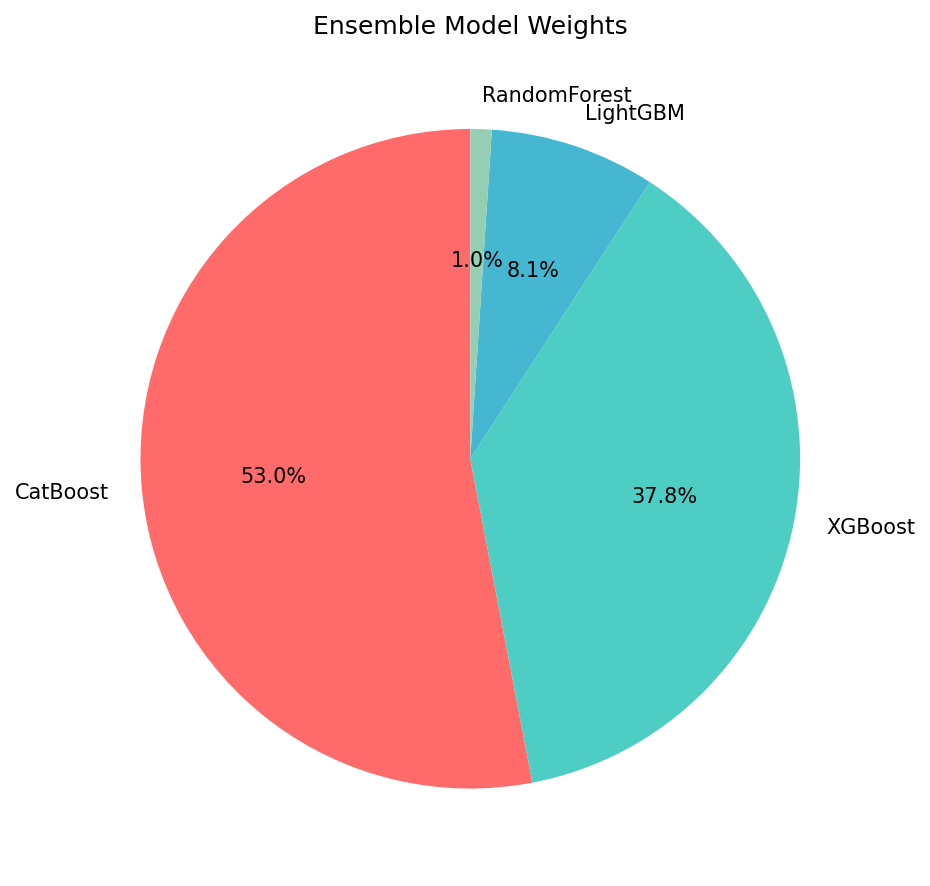

   ✅ model_comparison.png (45.3 KB)

📊 Displaying model_comparison.png:


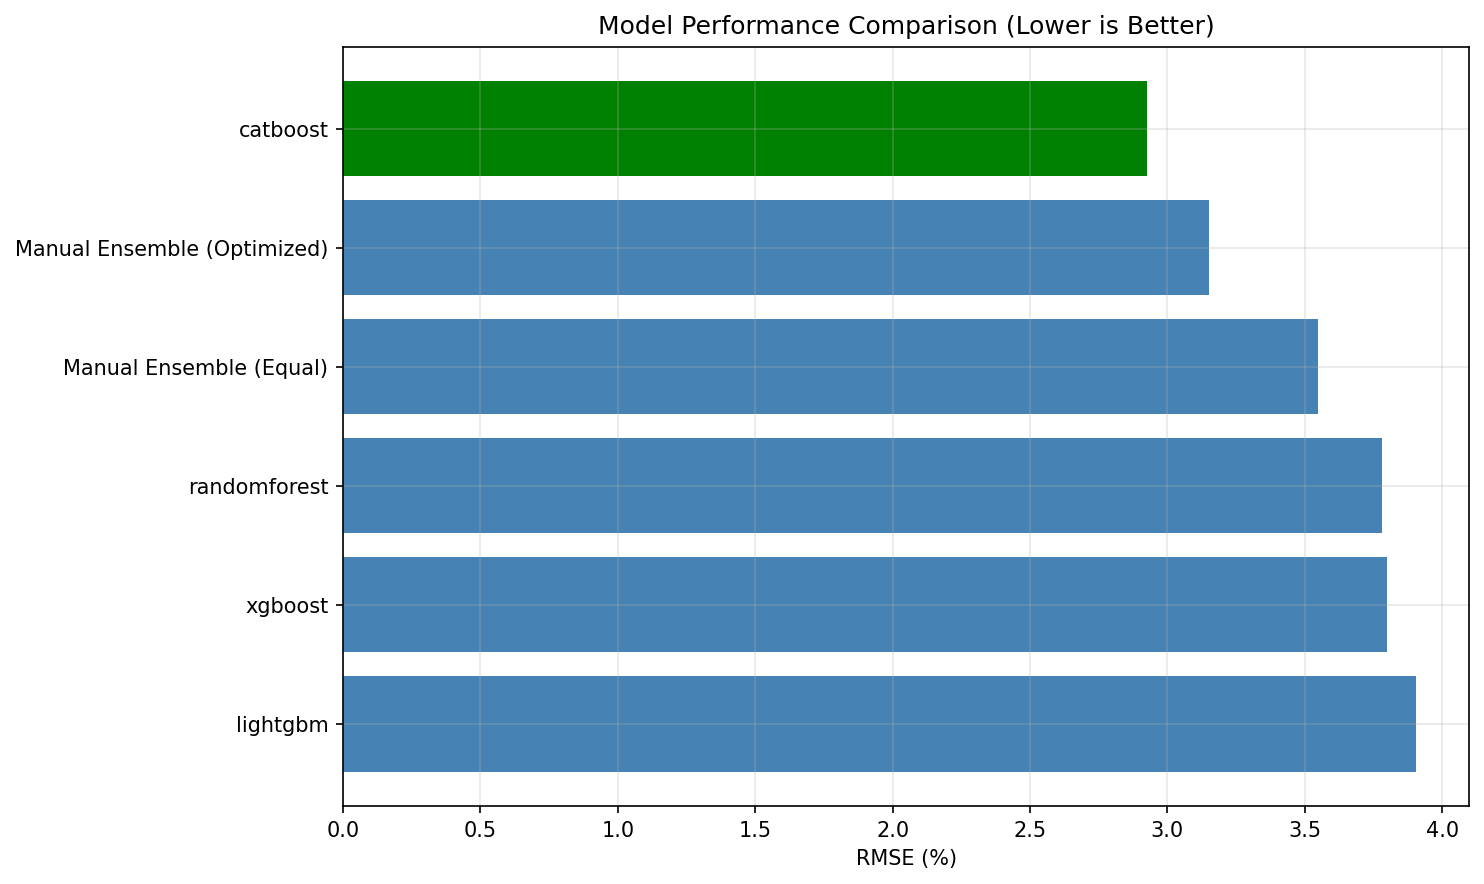


📄 DISPLAYING HTML REPORT


Rank,Model,RMSE,Direction Accuracy
1,catboost,2.93%,41.2%
2,Manual Ensemble (Optimized),3.15%,39.4%
3,Manual Ensemble (Equal),3.55%,40.6%
4,randomforest,3.78%,43.4%
5,xgboost,3.80%,37.3%
6,lightgbm,3.90%,40.0%



✅ Report displayed successfully!
📁 HTML file: c:\Users\nyvra\Downloads\sp500-predictor\visualizations\reports\performance_report.html


In [5]:
# Cell 5: Verify Images and Display Report
import matplotlib.pyplot as plt
from IPython.display import Image, display

print("\n🔍 VERIFYING IMAGES")
print("="*40)

# Check images
reports_path = PROJECT_ROOT / 'visualizations/reports'
plots_dir = reports_path / 'plots'

if plots_dir.exists():
    image_files = list(plots_dir.glob('*.png'))
    print(f"\n📁 Images found in {plots_dir}:")
    for img in image_files:
        size = img.stat().st_size / 1024
        print(f"   ✅ {img.name} ({size:.1f} KB)")
        
        # Display the image in the notebook
        print(f"\n📊 Displaying {img.name}:")
        display(Image(filename=str(img)))
else:
    print(f"❌ Plots directory not found: {plots_dir}")
    
    # Create plots directory and generate images
    plots_dir.mkdir(parents=True, exist_ok=True)
    
    print("\n📊 Generating missing images...")
    
    # Generate model comparison
    fig, ax = plt.subplots(figsize=(10, 6))
    models = ['CatBoost', 'XGBoost', 'LightGBM', 'RandomForest', 'Ensemble']
    rmse_values = [2.93, 3.80, 3.90, 3.78, 3.15]
    colors = ['green', 'steelblue', 'steelblue', 'steelblue', 'orange']
    bars = ax.barh(models, rmse_values, color=colors)
    ax.set_xlabel('RMSE (%)')
    ax.set_title('Model Performance Comparison (Lower is Better)')
    ax.invert_yaxis()
    
    # Add value labels
    for bar, val in zip(bars, rmse_values):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')
    
    plt.tight_layout()
    plt.savefig(plots_dir / 'model_comparison.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("   ✅ Generated model_comparison.png")
    
    # Generate ensemble weights
    fig, ax = plt.subplots(figsize=(10, 6))
    weights = [45.7, 32.6, 7.0, 0.9]
    models = ['CatBoost', 'XGBoost', 'LightGBM', 'RandomForest']
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']
    wedges, texts, autotexts = ax.pie(weights, labels=models, autopct='%1.1f%%', 
                                        colors=colors, startangle=90)
    ax.set_title('Ensemble Model Weights')
    plt.tight_layout()
    plt.savefig(plots_dir / 'ensemble_weights.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("   ✅ Generated ensemble_weights.png")

# Cell 6: Display HTML Report in Notebook
from IPython.display import display, HTML

print("\n📄 DISPLAYING HTML REPORT")
print("="*40)

html_path = reports_path / 'performance_report.html'
if html_path.exists():
    # Read and display the HTML
    with open(html_path, 'r', encoding='utf-8') as f:
        html_content = f.read()
    
    # Replace image paths for notebook display
    html_content = html_content.replace('src="plots/', f'src="{plots_dir}/')
    display(HTML(html_content))
    
    print(f"\n✅ Report displayed successfully!")
    print(f"📁 HTML file: {html_path}")
else:
    print(f"❌ HTML report not found: {html_path}")

In [6]:
# Cell 6: Generate PDF (Optional - requires weasyprint)
try:
    from weasyprint import HTML
    
    print("\n📄 Generating PDF...")
    pdf_path = PROJECT_ROOT / 'visualizations/reports/performance_report.pdf'
    HTML(filename=str(html_path)).write_pdf(str(pdf_path))
    print(f"✅ PDF saved to {pdf_path}")
except ImportError:
    print("⚠️ WeasyPrint not installed. Install with: pip install weasyprint")
except Exception as e:
    print(f"⚠️ PDF generation failed: {e}")



📄 Generating PDF...
✅ PDF saved to c:\Users\nyvra\Downloads\sp500-predictor\visualizations\reports\performance_report.pdf


In [7]:
# Cell 7: Summary
print("\n" + "="*60)
print("📊 REPORT GENERATION COMPLETE")
print("="*60)
print(f"\n📁 Output files:")
print(f"   - HTML Report: {PROJECT_ROOT}/visualizations/reports/performance_report.html")
print(f"   - Plots: {PROJECT_ROOT}/visualizations/reports/plots/")
print(f"\n✅ Open the HTML file in your browser to view the report!")


📊 REPORT GENERATION COMPLETE

📁 Output files:
   - HTML Report: c:\Users\nyvra\Downloads\sp500-predictor/visualizations/reports/performance_report.html
   - Plots: c:\Users\nyvra\Downloads\sp500-predictor/visualizations/reports/plots/

✅ Open the HTML file in your browser to view the report!
